In [2]:
import os
import json

DATASET_ROOT = r"E:\badminton prj\Z coor\Badminton-Court-Keypoint-Dataset-2"
SPLIT = "train"

annotation_path = os.path.join(DATASET_ROOT, SPLIT, "_annotations_clean.coco.json")

with open(annotation_path, "r") as f:
    data = json.load(f)

images = data["images"]
annotations = data["annotations"]

print("Total images:", len(images))
print("Total annotations:", len(annotations))

Total images: 5553
Total annotations: 11106


In [3]:
from collections import Counter

image_id_counts = {}

for ann in annotations:
    img_id = ann["image_id"]
    if img_id in image_id_counts:
        image_id_counts[img_id] += 1
    else:
        image_id_counts[img_id] = 1

print("Annotation distribution:", Counter(image_id_counts.values()))

Annotation distribution: Counter({2: 5553})


In [4]:
widths = []
heights = []

for img in images:
    widths.append(img["width"])
    heights.append(img["height"])

print("Min width:", min(widths))
print("Max width:", max(widths))
print("Unique resolutions:", len(set(zip(widths, heights))))

print("Min height:", min(heights))

Min width: 1920
Max width: 1920
Unique resolutions: 1
Min height: 1080


In [5]:
import numpy as np

all_x = []
all_y = []

for ann in annotations:
    keypoints = ann["keypoints"]

    for i in range(0, len(keypoints), 3):
        x = keypoints[i]
        y = keypoints[i+1]
        v = keypoints[i+2]

        if v > 0:
            all_x.append(x)
            all_y.append(y)

print("X range:", min(all_x), "to", max(all_x))
print("Y range:", min(all_y), "to", max(all_y))

X range: 325.4 to 1715.975
Y range: 410.525 to 1034.34


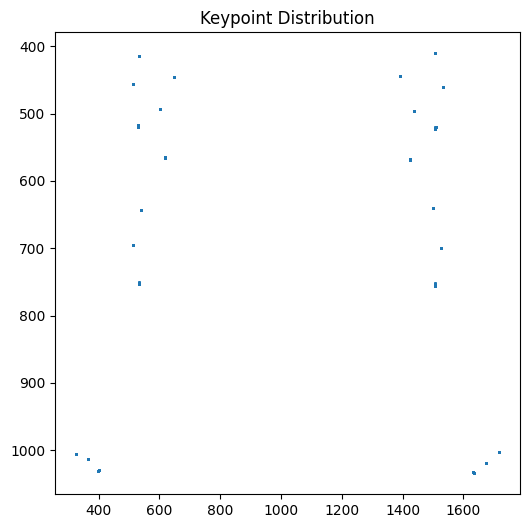

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(all_x, all_y, s=1)
plt.gca().invert_yaxis()
plt.title("Keypoint Distribution")
plt.show()

key point ko normalize karte 

In [7]:
import numpy as np

normalized_points = []

for ann in annotations:

    img = next(img for img in images if img["id"] == ann["image_id"])
    w = img["width"]
    h = img["height"]

    keypoints = ann["keypoints"]

    for i in range(0, len(keypoints), 3):

        x = keypoints[i]
        y = keypoints[i+1]
        v = keypoints[i+2]

        if v > 0:
            x_norm = x / w
            y_norm = y / h
            normalized_points.append((x_norm, y_norm))

xs = [p[0] for p in normalized_points]
ys = [p[1] for p in normalized_points]

print("Normalized X range:", min(xs), "to", max(xs))
print("Normalized Y range:", min(ys), "to", max(ys))

Normalized X range: 0.16947916666666665 to 0.8937369791666666
Normalized Y range: 0.3801157407407407 to 0.9577222222222221


In [8]:
bbox_widths = []
bbox_heights = []

for ann in annotations:

    bbox = ann["bbox"]   # [x, y, width, height]
    bw = bbox[2]
    bh = bbox[3]

    bbox_widths.append(bw)
    bbox_heights.append(bh)

print("BBox width range:", min(bbox_widths), "to", max(bbox_widths))
print("BBox height range:", min(bbox_heights), "to", max(bbox_heights))

BBox width range: 1029.903 to 1447.143
BBox height range: 260.313 to 673.1


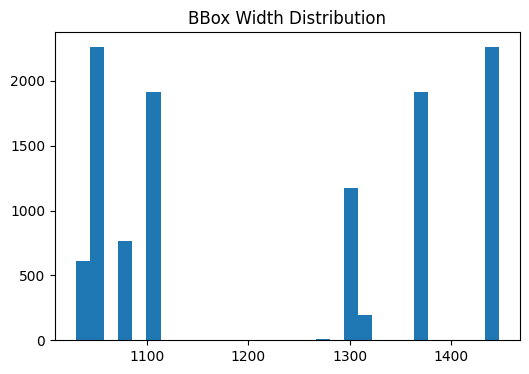

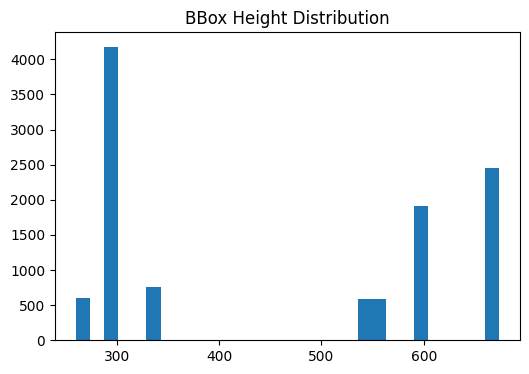

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(bbox_widths, bins=30)
plt.title("BBox Width Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(bbox_heights, bins=30)
plt.title("BBox Height Distribution")
plt.show()

court geometry 

In [10]:
import math

court_widths = []
court_heights = []

for ann in annotations:

    if ann["category_id"] != 2:
        continue

    keypoints = ann["keypoints"]

    points = []

    for i in range(0, len(keypoints), 3):
        x = keypoints[i]
        y = keypoints[i+1]
        points.append((x, y))

    # assuming order: TL, TR, BR, BL
    p1, p2, p3, p4 = points

    width_top = math.dist(p1, p2)
    width_bottom = math.dist(p4, p3)

    height_left = math.dist(p1, p4)
    height_right = math.dist(p2, p3)

    court_widths.append((width_top + width_bottom)/2)
    court_heights.append((height_left + height_right)/2)

print("Average court width:", sum(court_widths)/len(court_widths))
print("Average court height:", sum(court_heights)/len(court_heights))

Average court width: 587.9153033395535
Average court height: 1057.1536746546274


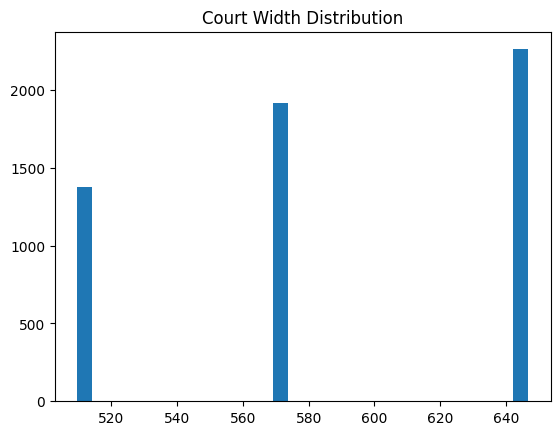

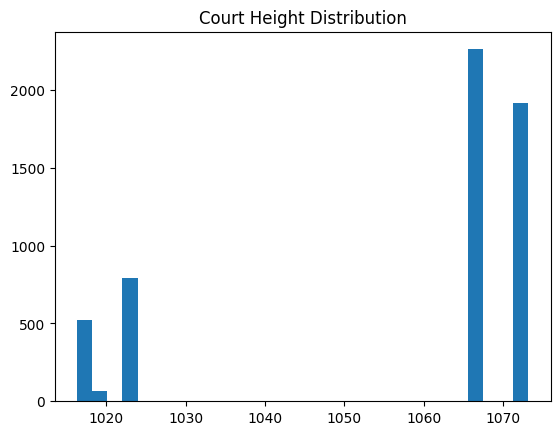

In [11]:
plt.hist(court_widths, bins=30)
plt.title("Court Width Distribution")
plt.show()

plt.hist(court_heights, bins=30)
plt.title("Court Height Distribution")
plt.show()

In [12]:
ratios = []

for w, h in zip(court_widths, court_heights):
    ratios.append(w / h)

print("Min ratio:", min(ratios))
print("Max ratio:", max(ratios))
print("Average ratio:", sum(ratios)/len(ratios))

Min ratio: 0.5003218658014066
Max ratio: 0.6066710700724413
Average ratio: 0.5555991116350089


RATIOS CONSISTENT HI AAYE mtlb tight hai ekdam range iska matlab annotation ache hue hai court consistency hai sab acha haii . good to gooo

In [13]:
import cv2
import matplotlib.pyplot as plt

def draw_annotations(image, anns):

    img = image.copy()

    for ann in anns:

        if ann["category_id"] == 2:
            color = (0, 255, 0)  # court → green
        else:
            color = (255, 0, 0)  # net → blue

        keypoints = ann["keypoints"]

        for i in range(0, len(keypoints), 3):

            x = int(keypoints[i])
            y = int(keypoints[i+1])
            v = keypoints[i+2]

            if v > 0:
                cv2.circle(img, (x, y), 6, color, -1)

    return img

In [14]:
# find first clean image (2 annotations)
for img_id, count in image_id_counts.items():
    if count == 2:
        test_id = img_id
        break

img_info = next(img for img in images if img["id"] == test_id)
img_path = os.path.join(DATASET_ROOT, SPLIT, img_info["file_name"])

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

anns = [ann for ann in annotations if ann["image_id"] == test_id]

In [15]:
import copy

def flip_image_and_anns(image, anns):

    h, w = image.shape[:2]
    flipped_img = cv2.flip(image, 1)

    flipped_anns = []

    for ann in anns:

        ann_copy = copy.deepcopy(ann)
        kps = ann_copy["keypoints"]

        # flip x
        for i in range(0, len(kps), 3):
            if kps[i+2] > 0:
                kps[i] = w - kps[i]

        # reorder TL,TR,BR,BL → TR,TL,BL,BR
        order = [1, 0, 3, 2]
        new_kps = [0]*len(kps)

        for new_i, old_i in enumerate(order):
            new_kps[new_i*3]     = kps[old_i*3]
            new_kps[new_i*3 + 1] = kps[old_i*3 + 1]
            new_kps[new_i*3 + 2] = kps[old_i*3 + 2]

        ann_copy["keypoints"] = new_kps
        flipped_anns.append(ann_copy)

    return flipped_img, flipped_anns


flipped_img, flipped_anns = flip_image_and_anns(image_rgb, anns)

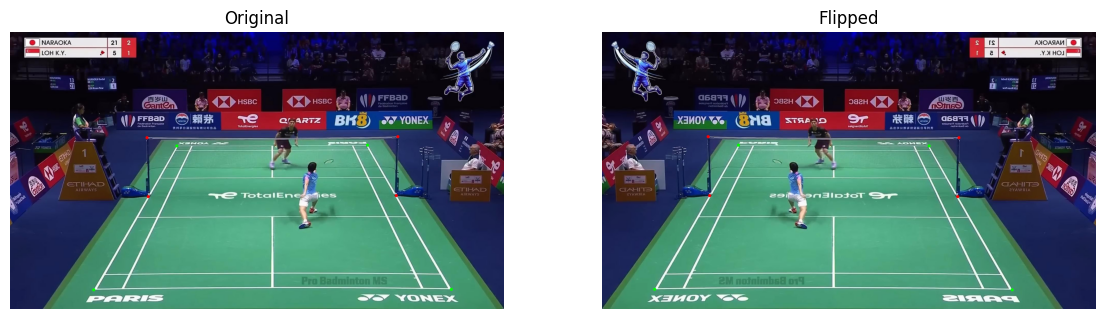

In [16]:
orig_vis = draw_annotations(image_rgb, anns)
flip_vis = draw_annotations(flipped_img, flipped_anns)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(orig_vis)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(flip_vis)
plt.title("Flipped")
plt.axis("off")

plt.show()

In [17]:
import math

def compute_ratio(ann):
    kps = ann["keypoints"]
    pts = [(kps[i], kps[i+1]) for i in range(0, len(kps), 3)]
    p1, p2, p3, p4 = pts

    width = (math.dist(p1, p2) + math.dist(p4, p3)) / 2
    height = (math.dist(p1, p4) + math.dist(p2, p3)) / 2

    return width / height


orig_ratio = compute_ratio(anns[0])
flip_ratio = compute_ratio(flipped_anns[0])

print("Original ratio:", orig_ratio)
print("Flipped ratio:", flip_ratio)

Original ratio: 0.6066710700724413
Flipped ratio: 0.6066710700724411


ratio nearly equal hai mtlab correct hua hai assumption keypoint ka 


In [18]:
import os
import cv2
import json
import copy
import numpy as np

AUG_FOLDER = os.path.join(DATASET_ROOT, "train_augmented")
os.makedirs(AUG_FOLDER, exist_ok=True)

In [19]:
image_to_annotations = {}

for ann in annotations:
    img_id = ann["image_id"]
    if img_id not in image_to_annotations:
        image_to_annotations[img_id] = []
    image_to_annotations[img_id].append(ann)

In [20]:
def flip_image_and_anns(image, anns):

    h, w = image.shape[:2]
    flipped_img = cv2.flip(image, 1)
    flipped_anns = []

    for ann in anns:
        ann_copy = copy.deepcopy(ann)
        kps = ann_copy["keypoints"]

        for i in range(0, len(kps), 3):
            if kps[i+2] > 0:
                kps[i] = w - kps[i]

        order = [1, 0, 3, 2]
        new_kps = [0]*len(kps)

        for new_i, old_i in enumerate(order):
            new_kps[new_i*3]     = kps[old_i*3]
            new_kps[new_i*3 + 1] = kps[old_i*3 + 1]
            new_kps[new_i*3 + 2] = kps[old_i*3 + 2]

        ann_copy["keypoints"] = new_kps
        flipped_anns.append(ann_copy)

    return flipped_img, flipped_anns

In [21]:
def adjust_brightness(image, alpha=1.0, beta=40):
    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

In [22]:
def rotate_image_and_anns(image, anns, angle):

    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_img = cv2.warpAffine(image, M, (w, h))

    rotated_anns = []

    for ann in anns:
        ann_copy = copy.deepcopy(ann)
        kps = ann_copy["keypoints"]

        for i in range(0, len(kps), 3):
            if kps[i+2] > 0:
                pt = np.array([kps[i], kps[i+1], 1])
                new_pt = M @ pt
                kps[i] = float(new_pt[0])
                kps[i+1] = float(new_pt[1])

        rotated_anns.append(ann_copy)

    return rotated_img, rotated_anns

In [23]:
new_images = []
new_annotations = []

new_img_id = 0
new_ann_id = 0

for img in images:

    img_path = os.path.join(DATASET_ROOT, SPLIT, img["file_name"])
    image = cv2.imread(img_path)

    anns = image_to_annotations[img["id"]]

    # ---------------- ORIGINAL ----------------
    filename = f"{new_img_id}_orig.jpg"
    cv2.imwrite(os.path.join(AUG_FOLDER, filename), image)

    img_copy = copy.deepcopy(img)
    img_copy["id"] = new_img_id
    img_copy["file_name"] = filename
    new_images.append(img_copy)

    for ann in anns:
        ann_copy = copy.deepcopy(ann)
        ann_copy["id"] = new_ann_id
        ann_copy["image_id"] = new_img_id
        new_annotations.append(ann_copy)
        new_ann_id += 1

    new_img_id += 1

    # ---------------- FLIP ----------------
    flip_img, flip_anns = flip_image_and_anns(image, anns)

    filename = f"{new_img_id}_flip.jpg"
    cv2.imwrite(os.path.join(AUG_FOLDER, filename), flip_img)

    img_copy = copy.deepcopy(img)
    img_copy["id"] = new_img_id
    img_copy["file_name"] = filename
    new_images.append(img_copy)

    for ann in flip_anns:
        ann["id"] = new_ann_id
        ann["image_id"] = new_img_id
        new_annotations.append(ann)
        new_ann_id += 1

    new_img_id += 1

    # ---------------- BRIGHTNESS ----------------
    bright_img = adjust_brightness(image)

    filename = f"{new_img_id}_bright.jpg"
    cv2.imwrite(os.path.join(AUG_FOLDER, filename), bright_img)

    img_copy = copy.deepcopy(img)
    img_copy["id"] = new_img_id
    img_copy["file_name"] = filename
    new_images.append(img_copy)

    for ann in anns:
        ann_copy = copy.deepcopy(ann)
        ann_copy["id"] = new_ann_id
        ann_copy["image_id"] = new_img_id
        new_annotations.append(ann_copy)
        new_ann_id += 1

    new_img_id += 1

    # ---------------- ROTATE +5 ----------------
    rot_img, rot_anns = rotate_image_and_anns(image, anns, 5)

    filename = f"{new_img_id}_rotp5.jpg"
    cv2.imwrite(os.path.join(AUG_FOLDER, filename), rot_img)

    img_copy = copy.deepcopy(img)
    img_copy["id"] = new_img_id
    img_copy["file_name"] = filename
    new_images.append(img_copy)

    for ann in rot_anns:
        ann["id"] = new_ann_id
        ann["image_id"] = new_img_id
        new_annotations.append(ann)
        new_ann_id += 1

    new_img_id += 1

    # ---------------- ROTATE -5 ----------------
    rot_img, rot_anns = rotate_image_and_anns(image, anns, -5)

    filename = f"{new_img_id}_rotn5.jpg"
    cv2.imwrite(os.path.join(AUG_FOLDER, filename), rot_img)

    img_copy = copy.deepcopy(img)
    img_copy["id"] = new_img_id
    img_copy["file_name"] = filename
    new_images.append(img_copy)

    for ann in rot_anns:
        ann["id"] = new_ann_id
        ann["image_id"] = new_img_id
        new_annotations.append(ann)
        new_ann_id += 1

    new_img_id += 1